In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression as LR
from sklearn.preprocessing import StandardScaler
from classic_ml_models.linear_models import LinearRegression, Lasso, Ridge, ElasticNet, SVM

from metrics.metrics import accuracy_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes

X, y = load_diabetes(return_X_y=True)

scaler = StandardScaler()

X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_train_linear = scaler.fit_transform(X_train_linear)
X_test_linear = scaler.transform(X_test_linear)

In [2]:
alpha = 1
learning_rate = 0.001
num_iter = 20000
l1_ratio = 0.5
C = 1


def print_and_save_info(model, weight, bias, loss):
    weights.append(weight)
    biases.append(bias)

    # print(f"Weights of {model}:\n {weight}")
    # print(f"Bias of {model}:\n {bias}")

    print(f"MSE of {model}: {loss}")
    print("-" * 50)

    return (weights, bias)

sk_linreg = LR()
linreg = LinearRegression(num_iter=num_iter, lr=learning_rate)
lasso = Lasso(num_iter=num_iter, alpha=alpha, lr=learning_rate)
ridge = Ridge(num_iter=num_iter, alpha=alpha, lr=learning_rate)
elasticnet = ElasticNet(
    num_iter=num_iter, alpha=alpha, l1_ratio=l1_ratio, lr=learning_rate
)

# learning regressions
models = (linreg, lasso, ridge, elasticnet, sk_linreg)
weights = []
biases = []
mean_squared_errors = []
for model in models:
    model.fit(X_train_linear, y_train_linear)
    predictions = model.predict(X_test_linear)
    loss = mean_squared_error(y_test_linear, predictions)
    mean_squared_errors.append(loss)

    if not isinstance(model, LR):
        weights, bias = print_and_save_info(
            model, model.weights, model.bias, loss
        )
    else:
        weights, bias = print_and_save_info(
            model, model.coef_, model.intercept_, loss
        )

Stopped on iteration 748
MSE of My LinearRegression: 4261.2595286519145
--------------------------------------------------
Stopped on iteration 747
MSE of Lasso: 4255.5052586101765
--------------------------------------------------
Stopped on iteration 737
MSE of Ridge: 4357.714453216305
--------------------------------------------------
Stopped on iteration 728
MSE of ElasticNet: 4408.405547578218
--------------------------------------------------
MSE of LinearRegression(): 2821.7509810013107
--------------------------------------------------


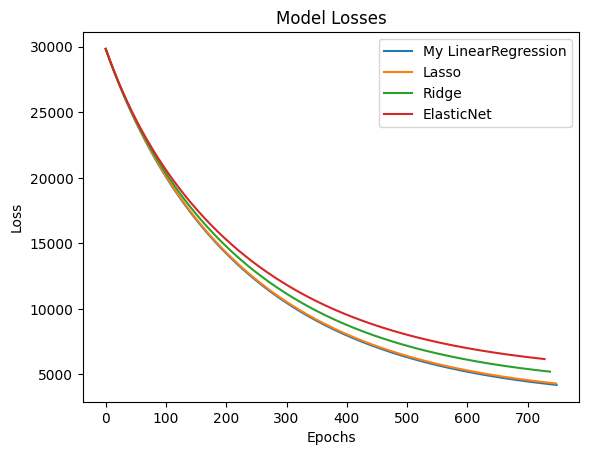

In [10]:
import matplotlib.pyplot as plt

for model in models[:-1]: 
    plt.plot(model.losses, label=f"{model}") 

plt.xlabel("Epochs")     
plt.ylabel("Loss")       
plt.title("Model Losses")
plt.legend()             
plt.show()               


In [4]:
params = pd.DataFrame({
    'model': models,
    'weights': weights,
    'bias': biases,
    'MSE': mean_squared_errors,
})

In [5]:
params

,model,weights,bias,MSE
0,My LinearRegression,"[2.3421574139368184, -8.086532123844187, 22.45...",119.476504,4261.259529
1,Lasso,"[2.0154290161200215, -7.533484851456944, 22.28...",119.407513,4255.505259
2,Ridge,"[2.2968558715479817, -4.117127987536335, 15.03...",118.709955,4357.714453
3,ElasticNet,"[2.199794765970242, -3.9461141327788374, 14.95...",118.070100,4408.405548
4,LinearRegression(),"[1.3524672442087808, -12.454268934391646, 26.2...",153.902913,2821.750981
